In [1]:
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, learning_curve, cross_val_score
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error
import pandas as pd

In [2]:
data = fetch_california_housing()
X = pd.DataFrame(data = data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

X.shape

(20640, 8)

In [ ]:
#scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
#splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

((14448, 8), (6192, 8))

In [5]:
model = DecisionTreeRegressor(random_state=42, max_depth=50)
model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,50
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [ ]:
# cek performa model di train dan test
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
print(f"Train MSE: {train_mse}")
print(f"Test MSE: {test_mse}")

Train MSE: 9.904697258622977e-32
Test MSE: 0.5280096503174904


# <font color='#8ce99a' face='Courier New'>Learning curve</font>

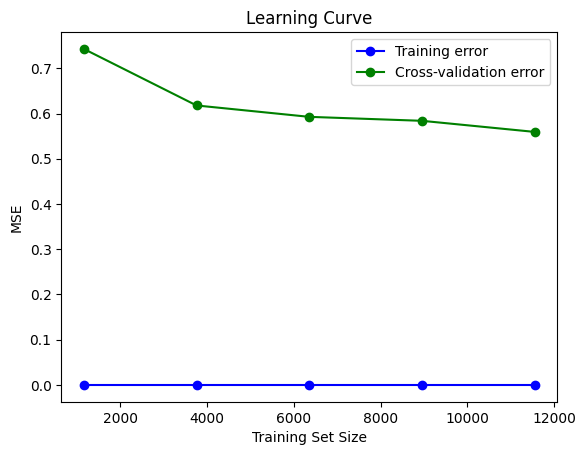

In [7]:
# Menghitung learning curve
train_sizes, train_scores, test_scores = learning_curve(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
 
# Menghitung rata-rata dan standar deviasi
train_mean = -np.mean(train_scores, axis=1)
test_mean = -np.mean(test_scores, axis=1)
 
# Plot learning curve
plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Training error")
plt.plot(train_sizes, test_mean, 'o-', color="green", label="Cross-validation error")
plt.title("Learning Curve")
plt.xlabel("Training Set Size")
plt.ylabel("MSE")
plt.legend()
plt.show()

# <font color='#8ce99a' face='Courier New'>Mengatasi Overfitting</font>

In [8]:
# Cross validation
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

print(f" Cross validation MSE: {-np.mean(cv_scores)}")

 Cross validation MSE: 0.556707958946337


In [ ]:
# Regularization dengan max_depth
model_new = DecisionTreeRegressor(random_state=42, max_depth=5)
model_new.fit(X_train, y_train)

y_train_pred = model_new.predict(X_train)
y_test_pred = model_new.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print(f"Train MSE: {train_mse}")
print(f"Test MSE: {test_mse}")

Train MSE: 0.4928096322147045
Test MSE: 0.5210801561811793


In [ ]:
# Prunning
path = model.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

print(f"CCP alphas terkecil: {ccp_alphas[0]}, CCP alphas terbesar: {ccp_alphas[-1]}")
# SEMAKIN BESAR CCP ALPHAS, SEMAKIN SEDERHANA MODELNYA
model_pruned = DecisionTreeRegressor(random_state=42, ccp_alpha=ccp_alphas[-2])
model_pruned.fit(X_train, y_train)

y_train_pred = model_pruned.predict(X_train)
y_test_pred = model_pruned.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print(f"Train MSE: {train_mse}")
print(f"Test MSE: {test_mse}")

CCP alphas terkecil: 0.0, CCP alphas terbesar: 0.42073395937170077
Train MSE: 0.9189620181001872
Test MSE: 0.9194598144703808


In [ ]:
# Data augmentation dengan menambahkan noise
X_train_aug = X_train + np.random.normal(0, 0.1, X_train.shape)
 
# Melatih ulang model dengan augmented data
model_aug = DecisionTreeRegressor(max_depth=10, random_state=42)
model_aug.fit(X_train_aug, y_train)
 
# Membuat prediksi
y_train_pred_aug = model_aug.predict(X_train_aug)
y_test_pred_aug = model_aug.predict(X_test)
 
# Menghitung MSE
train_mse_aug = mean_squared_error(y_train, y_train_pred_aug)
test_mse_aug = mean_squared_error(y_test, y_test_pred_aug)
 
print(f'Augmented Data Training MSE: {train_mse_aug}')
print(f'Augmented Data Test MSE: {test_mse_aug}')


((14448, 8), (14448,))